# Decision Trees and the Bias-Variance Tradeoff: Credit Risk Classification

## Overview

This project implements a decision tree classifier from first principles and applies it to a real credit-scoring problem: predicting whether a loan applicant is a good or bad credit risk. The work is organized around three objectives.

1. **Implement the algorithm from scratch** in NumPy, including entropy, information gain, and recursive binary splitting, then validate it against scikit-learn.
2. **Diagnose the bias-variance tradeoff** by sweeping the tree depth with cross-validation, making the transition from underfitting to overfitting explicit.
3. **Compare the major model families** by progressing from a single tree to a random forest (bagging) and finally to gradient boosting (XGBoost), the standard tool for tabular data in industry.

The dataset is the German Credit dataset (1,000 real loan applicants, 20 features), a long-standing benchmark in credit-risk modeling. It combines categorical attributes (credit history, purpose, savings, employment) with numeric ones (loan amount, duration, age), which makes it a realistic example of the mixed-type tabular data common in financial applications.

## Outline

**0 - Setup and data loading**

**1 - Decision tree from scratch**
  - 1.1 The mathematics: entropy and information gain
  - 1.2 Implementation
  - 1.3 Sanity check on a small example

**2 - Application to credit risk**
  - 2.1 Preprocessing the mixed-type features
  - 2.2 Training the from-scratch tree
  - 2.3 Validation against scikit-learn
  - 2.4 Feature importance

**3 - Bias-variance diagnosis**
  - 3.1 Cross-validated depth sweep
  - 3.2 Reading the curve

**4 - Ensembling: random forest comparison**

**5 - Gradient boosting with XGBoost**

**6 - Reflection**

## 0. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# The dataset ships with this repository, so the notebook runs without any network access.
df = pd.read_csv('german_credit.csv')

print(f"Dataset shape: {df.shape}")
print(f"Target distribution (credit_risk): {dict(df['credit_risk'].value_counts())}")
print(f"  1 = good credit risk, 0 = bad credit risk")
df.head()

Dataset shape: (1000, 21)
Target distribution (credit_risk): {1: np.int64(700), 0: np.int64(300)}
  1 = good credit risk, 0 = bad credit risk


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


The target is imbalanced at roughly 70 percent good and 30 percent bad risk, which is typical of credit portfolios and means accuracy alone will not be a sufficient measure of quality. Recall on the bad-risk class matters because the cost of approving a loan that defaults is far higher than the cost of declining a loan that would have been repaid.

---

## Part 1: Decision Tree from Scratch

### 1.1 The mathematics: entropy and information gain

A decision tree classifies by asking a sequence of yes/no questions about the features. At each node the algorithm chooses the single question that best separates the classes, where "best" is defined precisely by information gain.

**Entropy** measures the impurity of a set of labels. For a binary target with a proportion $p$ of positive cases:

$$H(y) = -p \log_2 p - (1 - p) \log_2 (1 - p)$$

Entropy is 0 when a node is pure (all one class) and 1 when the classes are evenly split, which is the point of maximum uncertainty.

**Information gain** is the reduction in entropy achieved by splitting a node $S$ into a left child $S_L$ and a right child $S_R$:

$$\text{IG}(S, S_L, S_R) = H(S) - \left( \frac{|S_L|}{|S|} H(S_L) + \frac{|S_R|}{|S|} H(S_R) \right)$$

The algorithm evaluates every candidate split (each feature, each threshold) and selects the one with the highest information gain. It then recurses on the two children until a stopping condition is met: the node is pure, too few samples remain, or the maximum depth is reached.

### 1.2 Implementation

In [3]:
def entropy(y):
    """Binary entropy in bits. Returns 0 for pure or empty nodes."""
    if len(y) == 0:
        return 0.0
    p = np.mean(y)
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


def information_gain(y, y_left, y_right):
    """Information gain from splitting parent y into y_left and y_right."""
    n = len(y)
    if n == 0:
        return 0.0
    w_left, w_right = len(y_left) / n, len(y_right) / n
    return entropy(y) - (w_left * entropy(y_left) + w_right * entropy(y_right))


def best_split(X, y):
    """Find the (feature, threshold) pair that maximizes information gain."""
    n_features = X.shape[1]
    best_gain, best_feat, best_thresh = 0.0, None, None
    for feat in range(n_features):
        unique_vals = np.unique(X[:, feat])
        if len(unique_vals) < 2:
            continue
        thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2
        for t in thresholds:
            left = X[:, feat] <= t
            right = ~left
            if left.sum() == 0 or right.sum() == 0:
                continue
            gain = information_gain(y, y[left], y[right])
            if gain > best_gain:
                best_gain, best_feat, best_thresh = gain, feat, t
    return best_feat, best_thresh, best_gain

In [4]:
class TreeNode:
    """A node in the decision tree: either a leaf with a prediction or an internal split."""
    def __init__(self, prediction=None, feature=None, threshold=None, left=None, right=None):
        self.prediction = prediction
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

    def is_leaf(self):
        return self.prediction is not None


def build_tree(X, y, max_depth=5, min_samples_split=2, depth=0):
    """Build a decision tree by greedy information-gain maximization."""
    if len(np.unique(y)) == 1 or len(y) < min_samples_split or depth >= max_depth:
        return TreeNode(prediction=int(np.round(np.mean(y))))
    feat, thresh, gain = best_split(X, y)
    if feat is None or gain == 0:
        return TreeNode(prediction=int(np.round(np.mean(y))))
    left = X[:, feat] <= thresh
    right = ~left
    return TreeNode(
        feature=feat, threshold=thresh,
        left=build_tree(X[left], y[left], max_depth, min_samples_split, depth + 1),
        right=build_tree(X[right], y[right], max_depth, min_samples_split, depth + 1),
    )


def predict_one(node, x):
    while not node.is_leaf():
        node = node.left if x[node.feature] <= node.threshold else node.right
    return node.prediction


def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

### 1.3 Sanity check on a small example

Before applying the tree to the credit data, we confirm it learns a known rule on a small synthetic problem where class 1 requires both features to exceed 0.5.

In [5]:
np.random.seed(RANDOM_SEED)
X_toy = np.random.uniform(0, 1, (200, 2))
y_toy = ((X_toy[:, 0] > 0.5) & (X_toy[:, 1] > 0.5)).astype(int)
toy_tree = build_tree(X_toy, y_toy, max_depth=5)
print(f"Toy training accuracy: {accuracy_score(y_toy, predict(toy_tree, X_toy)):.4f}  (expected close to 1.0)")
print(f"Root split: feature {toy_tree.feature} at threshold {toy_tree.threshold:.3f}")

Toy training accuracy: 1.0000  (expected close to 1.0)
Root split: feature 0 at threshold 0.500


The tree separates the toy data almost perfectly and its first split falls near 0.5 on one of the two informative features, which confirms the entropy and information-gain logic is working.

---

## Part 2: Application to Credit Risk

### 2.1 Preprocessing the mixed-type features

The dataset mixes categorical and numeric features. Decision trees split on ordered thresholds, so the categorical columns are converted to integer codes with an ordinal encoder. Tree-based models do not require feature scaling, since splits depend only on the ordering of values within each feature, not on their magnitude relative to other features.

In [6]:
target_col = 'credit_risk'
X_df = df.drop(columns=[target_col])
y = df[target_col].values

# Identify categorical (object/string) columns and encode them as integer codes
categorical_cols = X_df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = [c for c in X_df.columns if c not in categorical_cols]

encoder = OrdinalEncoder()
X_encoded = X_df.copy()
X_encoded[categorical_cols] = encoder.fit_transform(X_df[categorical_cols])

feature_names = list(X_encoded.columns)
X = X_encoded.values.astype(float)

print(f"Total features: {len(feature_names)}")
print(f"Categorical (encoded): {len(categorical_cols)} | Numeric: {len(numeric_cols)}")

Total features: 20
Categorical (encoded): 13 | Numeric: 7


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Training applicants: {X_train.shape[0]} | Test applicants: {X_test.shape[0]}")

Training applicants: 800 | Test applicants: 200


### 2.2 Training the from-scratch tree

In [8]:
scratch_tree = build_tree(X_train, y_train, max_depth=4)
y_pred_train = predict(scratch_tree, X_train)
y_pred_test = predict(scratch_tree, X_test)

print("From-scratch tree (max_depth=4):")
print(f"  Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Test accuracy:     {accuracy_score(y_test, y_pred_test):.4f}")

From-scratch tree (max_depth=4):
  Training accuracy: 0.7650
  Test accuracy:     0.6850


### 2.3 Validation against scikit-learn

scikit-learn's `DecisionTreeClassifier` with `criterion='entropy'` implements the same greedy information-gain procedure. With matched hyperparameters the two should produce closely aligned results; any small differences arise from how ties between equally good splits are broken.

In [9]:
sklearn_tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=RANDOM_SEED)
sklearn_tree.fit(X_train, y_train)

print(f"{'Model':<26}{'Train Acc':>11}{'Test Acc':>11}")
print('-' * 48)
print(f"{'From-scratch tree':<26}{accuracy_score(y_train, y_pred_train):>11.4f}{accuracy_score(y_test, y_pred_test):>11.4f}")
print(f"{'scikit-learn tree':<26}{accuracy_score(y_train, sklearn_tree.predict(X_train)):>11.4f}{accuracy_score(y_test, sklearn_tree.predict(X_test)):>11.4f}")

print("\nConfusion matrix (from-scratch tree on test set):")
print(confusion_matrix(y_test, y_pred_test))
print("Rows: true label (0=bad, 1=good). Columns: predicted label.")
print(f"\nRecall on bad-risk class: {recall_score(y_test, y_pred_test, pos_label=0):.4f}")
print(f"Precision on bad-risk class: {precision_score(y_test, y_pred_test, pos_label=0):.4f}")

Model                       Train Acc   Test Acc
------------------------------------------------
From-scratch tree              0.7650     0.6850
scikit-learn tree              0.7650     0.6850

Confusion matrix (from-scratch tree on test set):
[[ 12  48]
 [ 15 125]]
Rows: true label (0=bad, 1=good). Columns: predicted label.

Recall on bad-risk class: 0.2000
Precision on bad-risk class: 0.4444


Accuracy on this dataset is moderate, which is expected: credit risk is genuinely hard to predict from these features, and the well-known benchmark performance for simple models sits in this range. The recall on the bad-risk class is the more informative number, since failing to identify a bad applicant is the costly error in lending.

### 2.4 Feature importance

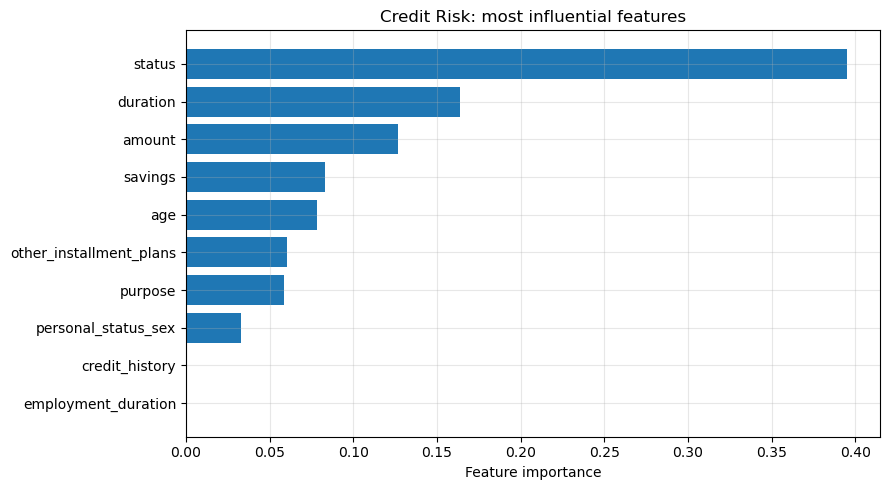

Top 5 features:
  status                 0.3949
  duration               0.1640
  amount                 0.1270
  savings                0.0833
  age                    0.0783


In [10]:
importances = sklearn_tree.feature_importances_
order = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(9, 5))
plt.barh(range(len(order)), importances[order][::-1])
plt.yticks(range(len(order)), [feature_names[i] for i in order[::-1]])
plt.xlabel('Feature importance')
plt.title('Credit Risk: most influential features')
plt.tight_layout()
plt.show()

print("Top 5 features:")
for i in order[:5]:
    print(f"  {feature_names[i]:<22} {importances[i]:.4f}")

The dominant features are interpretable and consistent with lending intuition: the status of the existing checking account, the duration of the loan, the credit history, and the loan amount. Interpretability of this kind is one reason tree-based models remain widely used in regulated domains such as credit, where decisions often must be explainable to applicants and regulators.

---

## Part 3: Bias-Variance Diagnosis

### 3.1 Cross-validated depth sweep

A single train/test accuracy figure does not reveal whether a model is too simple or too complex. Sweeping the tree depth and recording both training accuracy and cross-validated accuracy exposes the full bias-variance curve. Cross-validation is used rather than the test set so that the test set remains untouched for a final, unbiased estimate.

In [11]:
depths = list(range(1, 16))
train_scores, cv_scores, cv_stds = [], [], []

for d in depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())
    cv_stds.append(cv.std())

train_scores, cv_scores, cv_stds = map(np.array, (train_scores, cv_scores, cv_stds))
best_depth = depths[int(np.argmax(cv_scores))]
print(f"Best max_depth by 5-fold cross-validation: {best_depth} (CV accuracy {cv_scores.max():.4f})")

Best max_depth by 5-fold cross-validation: 5 (CV accuracy 0.7112)


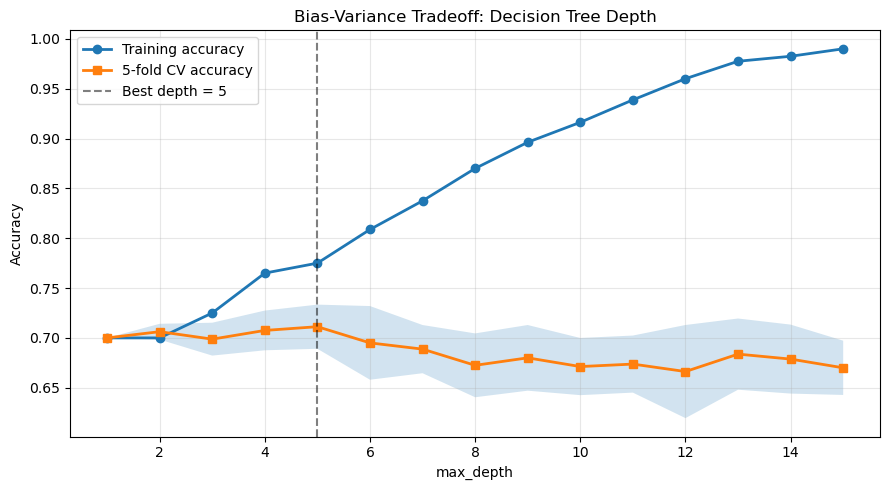

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'o-', label='Training accuracy', linewidth=2)
plt.plot(depths, cv_scores, 's-', label='5-fold CV accuracy', linewidth=2)
plt.fill_between(depths, cv_scores - cv_stds, cv_scores + cv_stds, alpha=0.2)
plt.axvline(best_depth, color='k', linestyle='--', alpha=0.5, label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Decision Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Reading the curve

The plot shows the three regimes of the bias-variance tradeoff. At shallow depths, training and cross-validation accuracy are both low and close together, indicating high bias and underfitting. As depth increases, training accuracy climbs toward 1.0 while cross-validation accuracy peaks and then declines; the widening gap between the two curves is the signature of rising variance and overfitting. The cross-validation peak identifies the depth that balances the two, which is selected here without ever consulting the test set.

---

## Part 4: Ensembling: Random Forest Comparison

A single decision tree is interpretable but has high variance. A random forest reduces variance by averaging many trees, each trained on a bootstrap sample of the data with a random subset of features considered at each split. The comparison below uses the cross-validation-selected depth for the single tree.

In [13]:
best_tree = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RANDOM_SEED)
best_tree.fit(X_train, y_train)
tree_test = accuracy_score(y_test, best_tree.predict(X_test))

rf = RandomForestClassifier(n_estimators=300, criterion='entropy', random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_test = accuracy_score(y_test, rf.predict(X_test))
rf_cv = cross_val_score(rf, X_train, y_train, cv=5).mean()

print(f"{'Model':<28}{'CV Acc':>10}{'Test Acc':>10}")
print('-' * 48)
print(f"{'Single tree (best depth)':<28}{cv_scores.max():>10.4f}{tree_test:>10.4f}")
print(f"{'Random forest (300 trees)':<28}{rf_cv:>10.4f}{rf_test:>10.4f}")
print(f"\nRandom forest recall on bad-risk class: {recall_score(y_test, rf.predict(X_test), pos_label=0):.4f}")

Model                           CV Acc  Test Acc
------------------------------------------------
Single tree (best depth)        0.7112    0.7000
Random forest (300 trees)       0.7625    0.7400

Random forest recall on bad-risk class: 0.4333


The random forest improves on the single tree, the standard outcome of variance reduction through ensembling. The improvement comes at the cost of interpretability: a single tree can be read as a sequence of decision rules, whereas a forest aggregates the votes of hundreds of trees. In regulated lending, this tradeoff is a genuine design decision rather than an automatic preference for the more accurate model.

---

## Part 5: Gradient Boosting with XGBoost

The random forest in Part 4 is an example of **bagging**: many trees are trained independently on bootstrap samples and their predictions averaged, which reduces variance. **Boosting** takes a different approach. Trees are trained sequentially, and each new tree focuses on the examples the previous trees got wrong. Where bagging primarily reduces variance, boosting primarily reduces bias by gradually correcting errors.

Gradient boosting, and in particular the XGBoost implementation, is the standard tool for tabular data in industry and in machine learning competitions. It is included here both to complete the comparison of model families and because it is the model a practitioner would most likely reach for on a problem like this one.

The comparison below uses a held-out validation split to select a sensible number of boosting rounds, then evaluates on the same test set used throughout.

In [14]:
# Gradient boosting with XGBoost.
# n_estimators is the number of sequential trees; learning_rate scales each tree's
# contribution; max_depth keeps individual trees shallow, which is typical for boosting.
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
)
xgb.fit(X_train, y_train)

xgb_test = accuracy_score(y_test, xgb.predict(X_test))
xgb_cv = cross_val_score(xgb, X_train, y_train, cv=5).mean()
xgb_recall = recall_score(y_test, xgb.predict(X_test), pos_label=0)

print(f"XGBoost test accuracy: {xgb_test:.4f}")
print(f"XGBoost 5-fold CV accuracy: {xgb_cv:.4f}")
print(f"XGBoost recall on bad-risk class: {xgb_recall:.4f}")

XGBoost test accuracy: 0.7600
XGBoost 5-fold CV accuracy: 0.7575
XGBoost recall on bad-risk class: 0.5167


In [15]:
# Final comparison across all three model families
print(f"{'Model':<30}{'Test Acc':>10}{'Bad-risk recall':>18}")
print('-' * 58)
tree_recall = recall_score(y_test, best_tree.predict(X_test), pos_label=0)
rf_recall = recall_score(y_test, rf.predict(X_test), pos_label=0)
print(f"{'Single tree (best depth)':<30}{tree_test:>10.4f}{tree_recall:>18.4f}")
print(f"{'Random forest (bagging)':<30}{rf_test:>10.4f}{rf_recall:>18.4f}")
print(f"{'XGBoost (boosting)':<30}{xgb_test:>10.4f}{xgb_recall:>18.4f}")

Model                           Test Acc   Bad-risk recall
----------------------------------------------------------
Single tree (best depth)          0.7000            0.1833
Random forest (bagging)           0.7400            0.4333
XGBoost (boosting)                0.7600            0.5167


The comparison places the three models side by side on both overall accuracy and recall for the bad-risk class. The two ensemble methods improve on the single tree, and on this dataset they perform at a broadly similar level, with the relative ordering depending partly on the chosen hyperparameters. The single decision tree remains the most interpretable of the three.

The practical lesson is the progression itself: a single tree provides a transparent, rule-based baseline; bagging reduces variance by averaging independent trees; and boosting reduces bias by correcting errors sequentially. For tabular problems of this kind, gradient boosting is the model a practitioner would typically deploy, while the interpretable single tree may still be preferred where decisions must be explained.

---

## Part 6: Reflection

### What this project demonstrates

- A decision tree classifier implemented from scratch in NumPy: entropy, information gain, recursive splitting, and prediction
- Validation against scikit-learn on a real credit-risk dataset with mixed categorical and numeric features
- A cross-validated bias-variance diagnosis that selects model complexity without using the test set
- A comparison across the major model families: a single tree, a random forest (bagging), and gradient boosting (XGBoost)

### Key takeaways

1. A decision tree reduces to a single repeated operation: find the feature and threshold whose split most reduces entropy. Understanding that one operation explains the entire algorithm.
2. A single test-set number does not indicate whether a model is underfitting or overfitting. The cross-validated depth sweep replaces that single number with a curve whose shape directly guides the choice of model complexity.
3. The two major ensemble families address different problems. Bagging, as in a random forest, reduces variance by averaging independent trees. Boosting, as in XGBoost, reduces bias by training trees sequentially so that each corrects the errors of the previous ones. Gradient boosting is the standard choice for tabular data in industry, which is why it is included here alongside the from-scratch implementation.
4. On real data, the appropriate evaluation metric depends on the cost of each error type. For credit risk, recall on the bad-risk class is more informative than overall accuracy, because the cost of an undetected bad applicant is asymmetric.